In [1]:
import xarray as xr
import numpy as np
from xgcm import Grid
import matplotlib.pyplot as plt


In [2]:
ds = xr.open_dataset('UV_equatorial.nc')

In [9]:
ds

<xarray.Dataset> Size: 119MB
Dimensions:  (k: 51, j: 540, i_g: 540, j_g: 540, i: 540)
Coordinates:
  * k        (k) int16 102B 0 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
  * j        (j) int16 1kB 3780 3781 3782 3783 3784 ... 4315 4316 4317 4318 4319
  * i_g      (i_g) int16 1kB 0 1 2 3 4 5 6 7 ... 532 533 534 535 536 537 538 539
  * j_g      (j_g) int16 1kB 3780 3781 3782 3783 3784 ... 4316 4317 4318 4319
  * i        (i) int16 1kB 0 1 2 3 4 5 6 7 8 ... 532 533 534 535 536 537 538 539
    time     datetime64[ns] 8B ...
    face     int16 2B ...
Data variables:
    U        (k, j, i_g) float32 59MB ...
    V        (k, j_g, i) float32 59MB ...
    drF      (k) float32 204B ...
    Z        (k) float32 204B ...

In [15]:
grid=Grid(ds, coords={"X": {"center": "i", "left": "i_g"},"Y":{"center": "j", "left": "j_g"}},autoparse_metadata=False)
grid

<xgcm.Grid>
X Axis (periodic, boundary='periodic'):
  * center   i --> left
  * left     i_g --> center
Y Axis (periodic, boundary='periodic'):
  * center   j --> left
  * left     j_g --> center

In [23]:
dsspeed = grid.interp(ds.U,'X') + grid.interp(ds.V,'Y')
cum_speed = dsspeed*ds.drF.cumsum('k')

In [32]:
slice1=np.zeros((51,100))

for i in range(0,100):
    slice1[:,i] = dsspeed .isel(i=slice(0,200)).isel(j=slice(0,200))[:,199-i*2,i].values

In [33]:
slice1.shape

(51, 100)

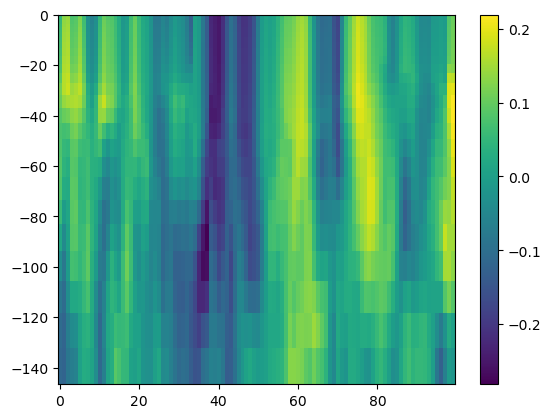

In [36]:
cs = plt.pcolormesh(np.arange(0,100),ds.Z[0:25],slice1[0:25])
plt.colorbar(cs)